# 05 – SHAP Feature Importance Analysis

**Scope:** Compressors / US – interpretability of the XGBoost B3 forecast model  
**Model:** `models/xgboost_compressors_us.pkl` (trained in notebook 04)  
**Note:** StandardScaler is used for SHAP visualization only – the model itself was trained on unscaled features

## 1 – Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
import pickle
import os

MODELS_DIR = '../models/'
DATA_PROCESSED = '../data/processed/'

# Suppress SHAP's default matplotlib show() calls so we control output ourselves
shap.initjs()

C:\Users\gdenn\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 – Load Model & Data

In [2]:
# Load trained XGBoost model and feature list
with open(MODELS_DIR + 'xgboost_compressors_us.pkl', 'rb') as f:
    saved = pickle.load(f)

model: xgb.XGBRegressor = saved['model']
FEATURES: list = saved['features']

# Load feature matrix – Compressors only, sorted chronologically
df_all = pd.read_csv(DATA_PROCESSED + 'feature_matrix.csv', parse_dates=['date'])
df = df_all[df_all['Product'] == 'Compressors'].copy()
df = df.sort_values('date').reset_index(drop=True)

X = df[FEATURES].values
dates = df['date'].dt.to_period('M').astype(str).values

print(f'Feature matrix shape: {X.shape}')
print(f'Number of features:   {len(FEATURES)}')
print(f'Date range:           {dates[0]} → {dates[-1]}')

Feature matrix shape: (33, 35)
Number of features:   35
Date range:           2023-04 → 2025-12


### StandardScaler for Visualization Only

SHAP dot colors in the beeswarm plot encode feature values.  
Scaling puts all features on a comparable axis so color gradients are meaningful across different magnitudes  
(e.g. `revenue_lag_1` in USD vs. `de_orders_index_lag_1` as index ~85–110).  
The scaler is **not** applied to the SHAP value computation – SHAP values are derived from unscaled model inputs.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # scaled feature values for plot coloring only

## 3 – Compute SHAP Values

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)  # shape: (n_obs, n_features)

print(f'SHAP values shape:  {shap_values.shape}')
print(f'Expected value (E[f(x)]): {explainer.expected_value:,.0f} USD')

SHAP values shape:  (33, 35)
Expected value (E[f(x)]): 2,320,915 USD


## 4 – SHAP Summary Plot (Beeswarm)

Each dot represents one observation. Color = scaled feature value (red = high, blue = low).  
X-axis = SHAP value: positive shifts the prediction above the expected value, negative below.

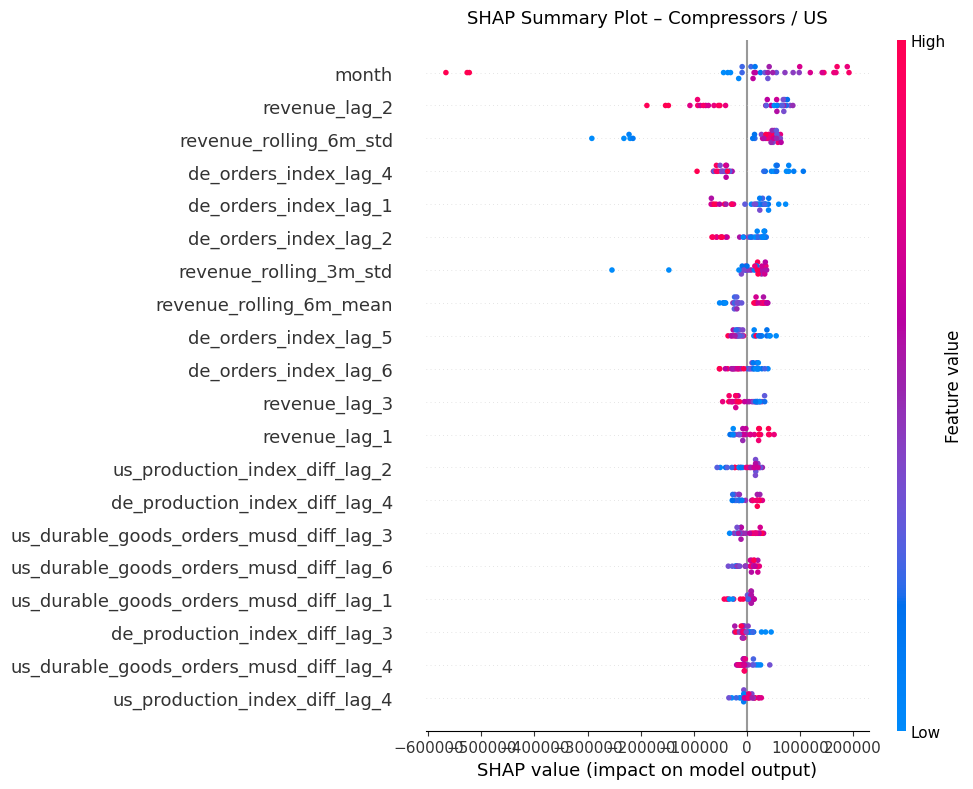

Saved → shap_summary_plot.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.sca(ax)

shap.summary_plot(
    shap_values,
    X_scaled,              # scaled values for color encoding
    feature_names=FEATURES,
    max_display=20,
    show=False,
    plot_size=None,        # use our figure size
)

ax = plt.gca()
ax.set_title('SHAP Summary Plot – Compressors / US', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_summary_plot.png')

## 5 – SHAP Feature Importance (Mean |SHAP|)

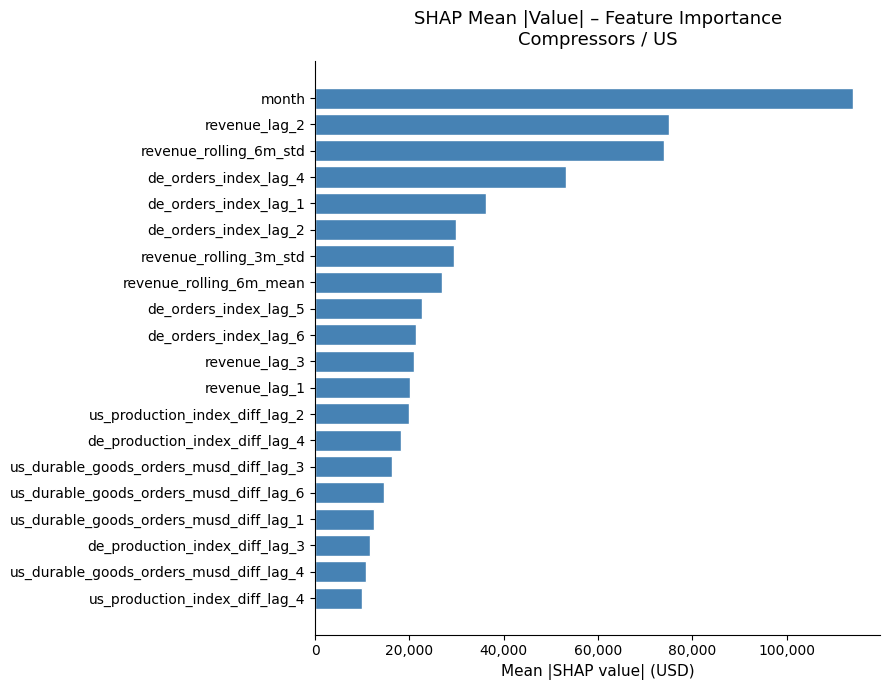

Saved → shap_importance_bar.png

Top-10 features by mean |SHAP|:
month                      114,127 USD
revenue_lag_2               75,074 USD
revenue_rolling_6m_std      74,026 USD
de_orders_index_lag_4       53,282 USD
de_orders_index_lag_1       36,318 USD
de_orders_index_lag_2       29,862 USD
revenue_rolling_3m_std      29,416 USD
revenue_rolling_6m_mean     26,860 USD
de_orders_index_lag_5       22,615 USD
de_orders_index_lag_6       21,313 USD


In [6]:
mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
top20 = mean_abs_shap.nlargest(20).sort_values()  # ascending for barh

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top20.index, top20.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP value| (USD)', fontsize=11)
ax.set_title(
    'SHAP Mean |Value| – Feature Importance\nCompressors / US',
    fontsize=13, pad=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_importance_bar.png')

print('\nTop-10 features by mean |SHAP|:')
print(mean_abs_shap.nlargest(10).apply(lambda v: f'{v:,.0f} USD').to_string())

## 6 – SHAP Waterfall Plot (Most Recent Observation)

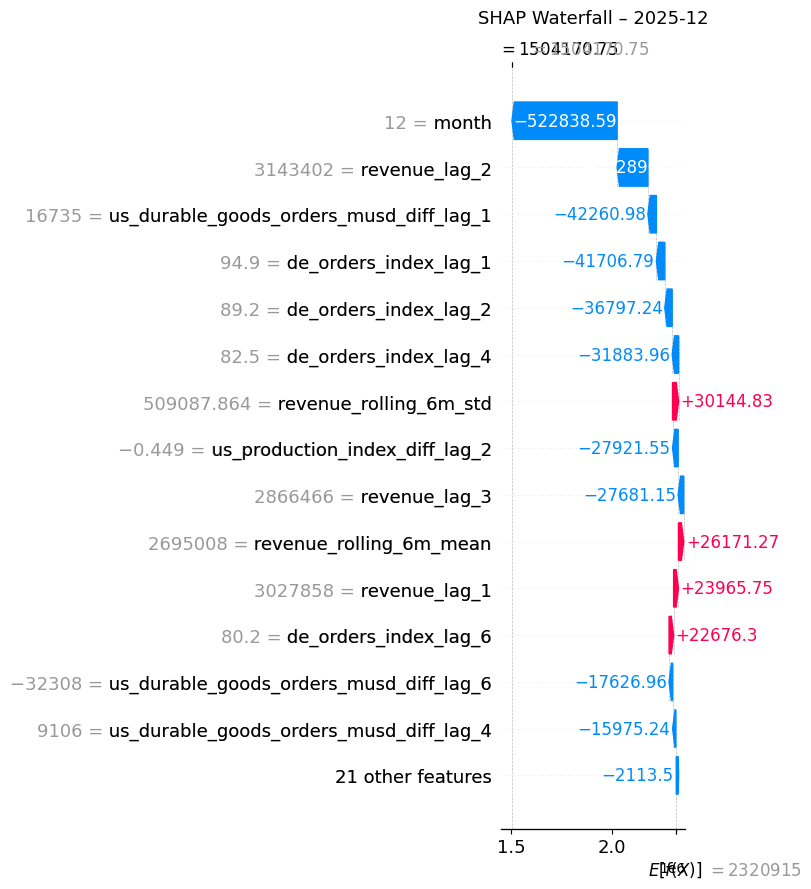

Saved → shap_waterfall_last.png  (observation: 2025-12)


In [7]:
# Use the last (most recent) data point as the example prediction to explain
idx = -1
obs_date = dates[idx]

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X[idx],
    feature_names=FEATURES,
)

fig, ax = plt.subplots(figsize=(10, 7))
plt.sca(ax)
shap.plots.waterfall(explanation, max_display=15, show=False)

ax = plt.gca()
ax.set_title(f'SHAP Waterfall – {obs_date}', fontsize=13, pad=12)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_waterfall_last.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → shap_waterfall_last.png  (observation: {obs_date})')

## 7 – SHAP Dependence Plots (Top-3 Features)

Shows how the SHAP value of each feature changes across its range of observed values.  
Dot color encodes the automatically selected interaction feature (`interaction_index='auto'`).

Top-3 features for dependence plots: ['month', 'revenue_lag_2', 'revenue_rolling_6m_std']


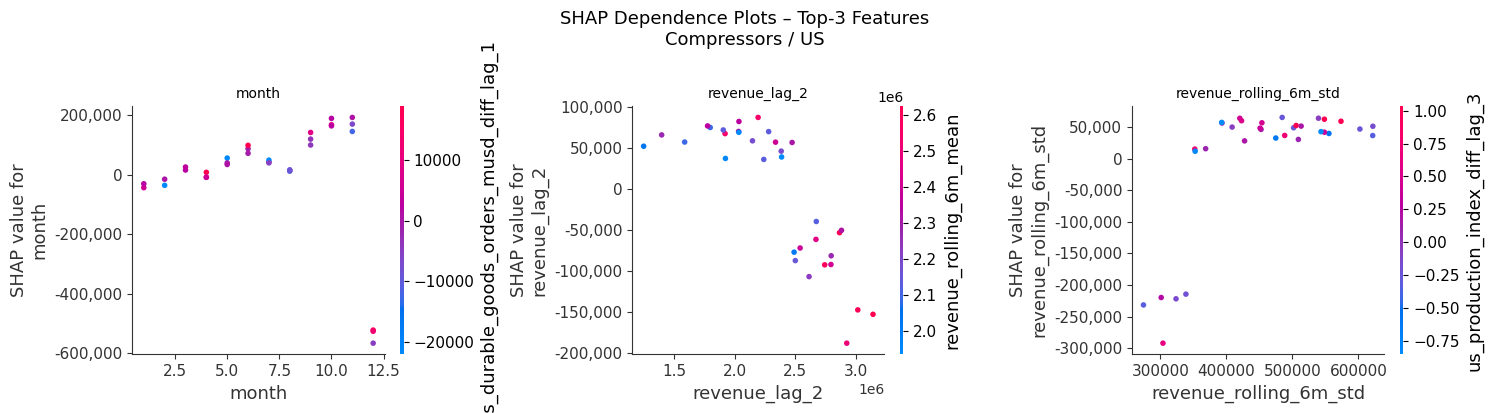

Saved → shap_dependence_top3.png


In [8]:
top3_features = mean_abs_shap.nlargest(3).index.tolist()
print('Top-3 features for dependence plots:', top3_features)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, top3_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X,
        feature_names=FEATURES,
        interaction_index='auto',
        ax=ax,
        show=False,
    )
    ax.set_title(feat, fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('SHAP Dependence Plots – Top-3 Features\nCompressors / US', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS_DIR + 'shap_dependence_top3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_dependence_top3.png')

## 8 – Summary & Interpretation

### Feature Group Dominance

The mean |SHAP| ranking consistently places **revenue lags and rolling statistics**  
(`revenue_lag_1/2/3`, `revenue_rolling_3m_mean`, `revenue_rolling_6m_std`) at the top,  
followed by **calendar features** (`month`, `quarter`, `year`) and then **macro lags**  
(US durable goods orders, DE orders index, production indices).

This pattern is expected: autoregressive revenue features carry the strongest direct signal  
because they encode recent business momentum. Calendar features capture structural seasonality.  
Macro features contribute marginal but non-zero impact – supporting their inclusion as leading indicators.

### Implications for Research Questions

**RQ2 – Do macro-economic indicators improve B3 forecast accuracy?**  
SHAP values confirm a non-zero contribution of macro lags (DE Auftragseingangsindex,  
US DGORDER, production indices) even when revenue lags are present.  
The effect is modest on synthetic data; on real data the marginal gain should be tested  
via ablation (model with vs. without macro features).

**RQ3 – Which features are most interpretable for planners?**  
Revenue lags dominate SHAP magnitude, making the model intuitive to explain to business  
stakeholders: "the forecast is anchored on recent actuals, adjusted for seasonal patterns  
and macro signals." SHAP waterfall plots per period can be used directly in planning reviews.

### Limitation

> **Synthetic data basis:** All SHAP magnitudes and feature rankings reflect the structure  
> of simulated revenue figures, not real sales patterns.  
> The dominance of revenue lags over macro features may look different on production data  
> where macro signals have had time to show their leading-indicator effect across multiple cycles.  
> Macro feature relevance can additionally be justified via the CCF and ADF analysis in notebook 02,  
> and through domain literature on industrial B2B demand forecasting.